# `grayt` demo — backward ray tracing around Kerr black holes

A hands-on tour of the public API of **`grayt`** (the Python layer of
GRAVTRACER, a replication of *OSIRIS*, arXiv:2202.00086).

Contents:

1. Spacetime basics — `BlackHole`, horizon and ISCO
2. Rendering a Page–Thorne thin-disk image and inspecting the raw per-pixel maps
3. Page–Thorne flux profiles for several spins
4. Single geodesics — `trace`, `orbit_ic`, `plot_orbits_2d`
5. "Photograph" mode — imaging a picture placed behind the hole
6. A 3D scene with traced rays
7. What happens on bad input

Every render below is kept small (≤ 512×256) so the whole notebook runs in
about a minute on a laptop. Figures are also saved to `output/`.

**Requirement:** `grayt` importable, plus numpy/matplotlib. The simplest route
is to install the package once from the repo root with `uv pip install -e .`.
If you would rather not install it, running this notebook from anywhere inside
the repo also works: the setup cell falls back to the `python/` source tree,
which then needs the compiled core (`make` in the repo root). Either way there
are no paths to edit by hand.

In [2]:
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Find the repo root by walking up from the working directory instead of
# hardcoding it, so the notebook runs from any clone and any cwd inside it.
_here = Path.cwd().resolve()
_repo = next((d for d in (_here, *_here.parents)
              if (d / "pyproject.toml").is_file()
              and (d / "python" / "grayt").is_dir()), None)

try:
    import grayt                      # installed, e.g. `uv pip install -e .`
except ImportError:
    if _repo is None:
        raise ImportError(
            f"grayt is not installed and no source checkout was found above {_here}. "
            "Run `uv pip install -e .` in the repo root, or start Jupyter there."
        ) from None
    sys.path.insert(0, str(_repo / "python"))   # uninstalled checkout + `make`
    import grayt

grayt.style.use()   # black field and serif type for every figure below

REPO = _repo or _here
OUT = REPO / "output"
OUT.mkdir(exist_ok=True)
ASSETS = REPO / "examples" / "assets"

print("grayt version:", grayt.__version__)
print("repo root    :", REPO)
print("public API   :", ", ".join(grayt.__all__))
if _repo is None:
    print("note         : not running inside a checkout, so figures go to "
          f"{OUT} and section 5 (photograph) has no texture to load.")

grayt version: 0.2.0
repo root    : /Users/blancus/Biblioteca/Papers/Gravitation/GRAVTRACER
public API   : Spacetime, BlackHole, QMetric, PlanarSurface, bl_to_cart, cart_to_bl, null_momentum, ThinDisk, ImageSource, Camera, Screen, Image, Photograph, Ray, Trajectory, render, shadow, trace, camera_ray, orbit_ic, flux_profile, PhysicalSystem, System, plot_orbits_2d, plot_image, plot_shadow, plot_lensing, STATUS_ESCAPED, STATUS_CAPTURED, STATUS_DISK, STATUS_FAILED


## 1. The spacetime: `grayt.BlackHole`

A frozen dataclass with a single parameter, the dimensionless spin `a`
(geometrized units, $M = 1$). `.horizon` and `.isco` call into the Fortran
core. The `repr` is the plain dataclass one, which is perfectly readable.

In [3]:
bh = grayt.BlackHole(a=0.9)
print(bh)                       # dataclass repr: BlackHole(a=0.9)
print("outer horizon r_H  =", bh.horizon)
print("prograde ISCO      =", bh.isco)

print()
for a in (0.0, 0.5, 0.9, 0.998):
    b = grayt.BlackHole(a=a)
    print(f"a = {a:5.3f}   r_H = {b.horizon:.4f}   r_ISCO = {b.isco:.4f}")

BlackHole(a=0.9)
outer horizon r_H  = 1.4358898943540672
prograde ISCO      = 2.320883041761887

a = 0.000   r_H = 2.0000   r_ISCO = 6.0000
a = 0.500   r_H = 1.8660   r_ISCO = 4.2330
a = 0.900   r_H = 1.4359   r_ISCO = 2.3209
a = 0.998   r_H = 1.0632   r_ISCO = 1.2370


How discoverable is the main entry point? `help(grayt.render)` gives the
full signature with type hints and defaults, plus a two-line physics summary
citing the equation it implements — short but genuinely useful.

In [4]:
help(grayt.render)

Help on function render in module grayt.api:

render(
    spacetime: 'Spacetime',
    camera: 'Camera',
    disk: 'ThinDisk | None' = None,
    method: 'str' = 'rkdp45',
    rtol: 'float' = 1e-08,
    atol: 'float' = 1e-10,
    max_steps: 'int' = 500000
) -> 'Image'
    Trace every pixel of ``camera`` through ``spacetime``; if ``disk``
    is given, shade disk intersections with I_obs = g^3 * F_PageThorne
    (eq. 19 of arXiv:2202.00086). The disk model is Kerr-only.



## 2. Rendering a thin-disk image

Compose three ingredients and render. Conventions to keep in mind (all stated
in the `Camera` docstring — read it, it matters):

* `Camera.theta` is in **degrees** (Boyer–Lindquist observer inclination);
* image-plane extents `x`, `y` are in units of $M$;
* `resolution` is `(nx, ny)` and all returned maps are `(nx, ny)` —
  x first, so transpose before `imshow`.

`ThinDisk(l0=1.8)` sets the constant specific angular momentum of the disk
matter; `r_in=None` defaults to the ISCO of whatever hole you render.

render: 8.2 s for 73728 pixels


Text(0.5, 1.0, 'Page-Thorne thin disk, edge-on-ish view')

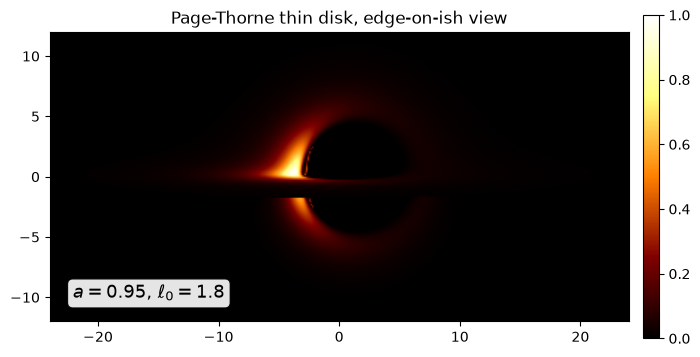

In [23]:
bh95 = grayt.BlackHole(a=0.95)
cam  = grayt.Camera(r=1000, theta=85, x=(-24, 24), y=(-12, 12),
                    resolution=(384, 192))
disk = grayt.ThinDisk(l0=1.8, r_out=20)

t0 = time.time()
img = grayt.render(bh95, cam, disk)          # no progress output; ~5-10 s
print(f"render: {time.time()-t0:.1f} s for {cam.resolution[0]*cam.resolution[1]} pixels")

ax = img.plot(label="$a=0.95$, $\\ell_0=1.8$")
ax.set_title("Page-Thorne thin disk, edge-on-ish view")


The bolometric intensity $I_{\rm obs} = g^3 F_{\rm PT}$ shows the
Doppler-boosted approaching side at $x<0$ (the paper's convention) and the
lensed far side of the disk arching over the shadow.

### Inspecting the raw per-pixel maps

`Image` is a plain dataclass of numpy arrays — very friendly for interactive
work: `intensity`, `g` (redshift factor), `r_hit` (Boyer–Lindquist radius of
the disk intersection), `status` (0 escaped / 1 captured / 2 disk / 3 failed,
with module-level `STATUS_*` constants), `herr` (Hamiltonian constraint
error), and the escape direction `theta_inf`, `phi_inf`.

shapes  : (384, 192) (384, 192) (384, 192)
status  : {0: 24747, 1: 1744, 2: 47237}  (0=escaped, 1=captured, 2=disk)
g on disk    : [0.189, 1.060]
r_hit on disk: [1.940, 20.000]  (ISCO = 1.937)
max constraint error: 7.784467994610449e-05


Text(0.5, 1.0, 'histogram of $g$ on the disk')

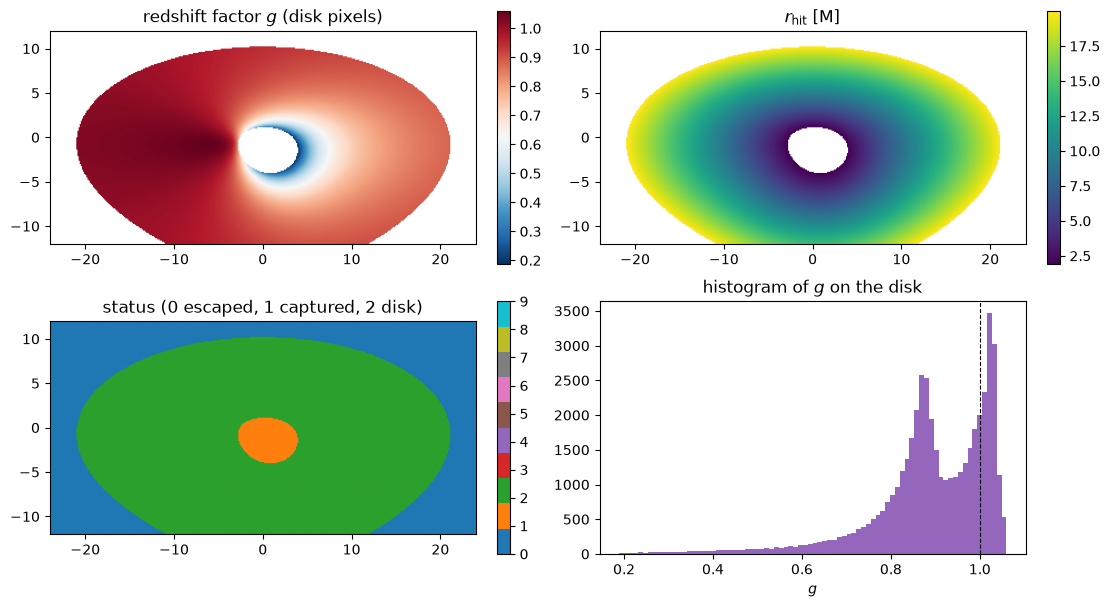

In [13]:
print("shapes  :", img.intensity.shape, img.g.shape, img.status.shape)
vals, counts = np.unique(img.status, return_counts=True)
print("status  :", dict(zip(vals.tolist(), counts.tolist())),
      " (0=escaped, 1=captured, 2=disk)")
dm = img.status == grayt.STATUS_DISK
print(f"g on disk    : [{img.g[dm].min():.3f}, {img.g[dm].max():.3f}]")
print(f"r_hit on disk: [{img.r_hit[dm].min():.3f}, {img.r_hit[dm].max():.3f}]"
      f"  (ISCO = {bh95.isco:.3f})")
print("max constraint error:", img.herr.max())

fig, axes = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True)
m0 = axes[0, 0].imshow(np.where(dm, img.g, np.nan).T, origin="lower",
                       extent=img.extent, cmap="RdBu_r", aspect="equal")
axes[0, 0].set_title("redshift factor $g$ (disk pixels)")
fig.colorbar(m0, ax=axes[0, 0])
m1 = axes[0, 1].imshow(np.where(dm, img.r_hit, np.nan).T, origin="lower",
                       extent=img.extent, cmap="viridis", aspect="equal")
axes[0, 1].set_title("$r_{\\rm hit}$ [M]")
fig.colorbar(m1, ax=axes[0, 1])
m2 = axes[1, 0].imshow(img.status.T, origin="lower", extent=img.extent,
                       cmap="tab10", vmin=0, vmax=9, aspect="equal")
axes[1, 0].set_title("status (0 escaped, 1 captured, 2 disk)")
fig.colorbar(m2, ax=axes[1, 0])
axes[1, 1].hist(img.g[dm].ravel(), bins=80, color="tab:purple")
axes[1, 1].axvline(1.0, color="k", lw=0.8, ls="--")
axes[1, 1].set_xlabel("$g$")
axes[1, 1].set_title("histogram of $g$ on the disk")

Blue-shifted pixels ($g>1$, up to $\sim 1.2$) sit exactly on the
approaching side; `r_hit` bottoms out at the ISCO because `r_in=None`
defaulted there. The maps are self-consistent and easy to slice — this part
of the API is a pleasure.

One nit: typing `img` alone in a cell dumps the full dataclass repr of seven
arrays (~3 kB of text). Harmless, but a custom `__repr__` would be kinder.

## 3. Page–Thorne flux profiles

`grayt.flux_profile(bh, r_out, n)` returns a bare `(r, F)` tuple sampled on
$[r_{\rm ISCO}, r_{\rm out}]$.

a=0.0: profile starts at r=6.0000 (ISCO 6.0000), peak F=1.719e-04 at r=9.551
a=0.5: profile starts at r=4.2330 (ISCO 4.2330), peak F=5.359e-04 at r=6.615
a=0.9: profile starts at r=2.3209 (ISCO 2.3209), peak F=4.263e-03 at r=3.444


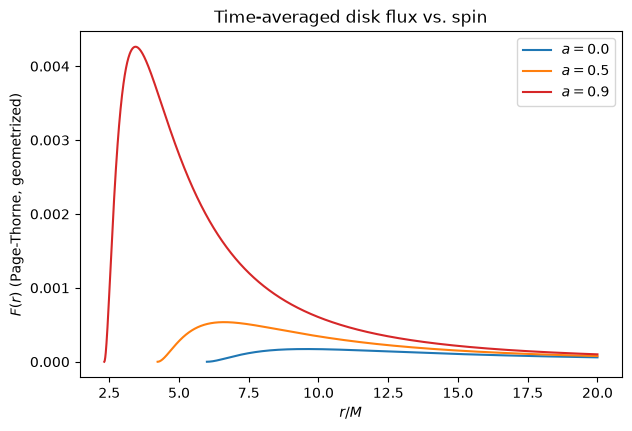

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for a, color in [(0.0, "tab:blue"), (0.5, "tab:orange"), (0.9, "tab:red")]:
    b = grayt.BlackHole(a=a)
    rs, fs = grayt.flux_profile(b, r_out=20.0)
    print(f"a={a}: profile starts at r={rs[0]:.4f} (ISCO {b.isco:.4f}), "
          f"peak F={fs.max():.3e} at r={rs[np.argmax(fs)]:.3f}")
    ax.plot(rs, fs, color=color, label=f"$a={a}$")
ax.set_xlabel("$r/M$")
ax.set_ylabel("$F(r)$ (Page-Thorne, geometrized)")
ax.set_title("Time-averaged disk flux vs. spin")
ax.legend()

Higher spin drags the ISCO inward and raises the peak flux by more than
an order of magnitude between $a=0$ and $a=0.9$ — the standard result, easy
to reproduce in six lines.

## 4. Single geodesics

`grayt.trace` integrates one geodesic from raw initial conditions
`y0 = (t, r, theta, phi, p_r, p_theta)` plus the conserved `p_t`, `p_phi`,
and returns a `Trajectory` dataclass of trajectory columns. Attribute access
(`traj.r`) and the older dict-style access (`traj["r"]`) both work, so it
stays convenient for plotting. Watch the units seam: here `theta` is in
**radians**, while `Camera.theta` and `orbit_ic(theta0=...)` are in degrees.

`grayt.orbit_ic` builds `(y0, p_t, p_phi)` from conserved $(E, L)$ —
`mass=1` (default) gives a time-like orbit, `mass=0` a photon.

trace returns: Trajectory with columns lam, t, r, theta, phi, p_r, p_theta, herr, meta
points: 249  max |constraint err|: 0.0003927131864396553


Text(0.5, 1.0, 'time-like rosette, $a=0$')

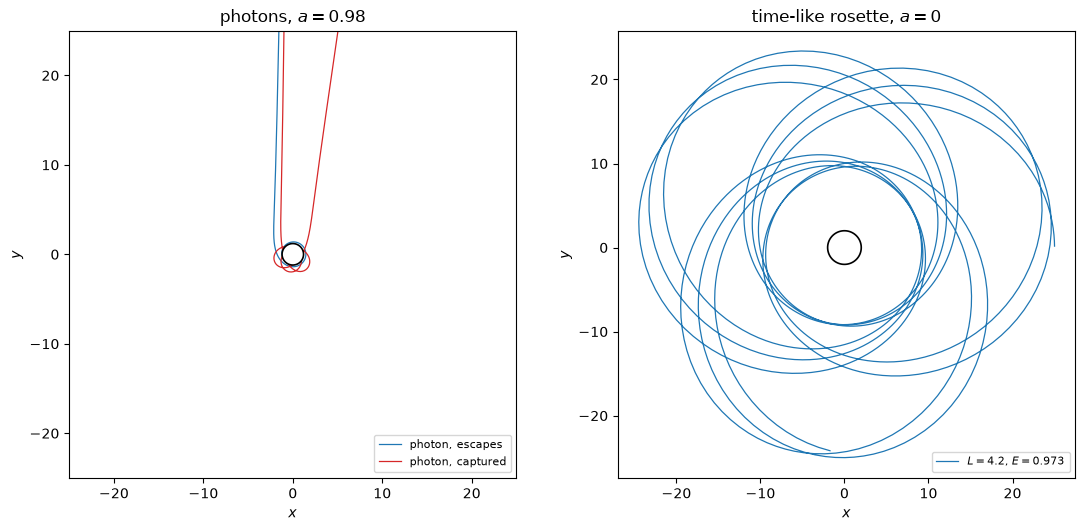

In [15]:
from dataclasses import fields

bh98 = grayt.BlackHole(a=0.98)
esc  = grayt.trace(bh98, [0, 100, np.pi/2, np.pi/2, -1.009327, 1.87],
                   p_t=-0.989953, p_phi=2.000098, lambda_max=220.0)
fall = grayt.trace(bh98, [0, 100, np.pi/2, np.pi/2, -1.009314, 3.75],
                   p_t=-0.989952, p_phi=1.250061, lambda_max=140.0)
print("trace returns:", type(esc).__name__, "with columns",
      ", ".join(f.name for f in fields(esc)))
print("points:", len(esc["r"]), " max |constraint err|:",
      np.abs(esc["herr"]).max())          # dict-style access still works

# time-like bound orbit: turning point at r0 = 25 M around a = 0
bh0 = grayt.BlackHole(a=0.0)
r0, L = 25.0, 4.2
E = np.sqrt((1 - 2/r0)*(1 + L*L/(r0*r0)))      # dr/dlambda = 0 at r0
y0, pt, pphi = grayt.orbit_ic(bh0, r0, E, L)
orb = grayt.trace(bh0, y0, p_t=pt, p_phi=pphi, lambda_max=4000.0,
                  n_max=100_000)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), constrained_layout=True)
grayt.plot_orbits_2d([(esc, "photon, escapes"), (fall, "photon, captured")],
                     black_hole=bh98, ax=axes[0],
                     colors=["tab:blue", "tab:red"])
axes[0].set_xlim(-25, 25); axes[0].set_ylim(-25, 25)
axes[0].set_title("photons, $a=0.98$")
grayt.plot_orbits_2d([(orb, f"$L={L}$, $E={E:.3f}$")], black_hole=bh0,
                     ax=axes[1])
axes[1].set_title("time-like rosette, $a=0$")

`plot_orbits_2d` is unusually flexible for a helper: it accepts trace
dicts, `Ray` objects, or bare `(N, 3)` arrays, optionally `(orbit, label)`
tuples, draws the horizon, and composes onto any axis you hand it.

## 5. Photograph mode: imaging a picture through the spacetime

Place a Lambertian "card" with a loaded image behind the hole and photograph
it with backward ray tracing: one ray per camera pixel, terminated on the
source plane, texture sampled where it lands. Note the scene layer uses
pseudo-Cartesian positions (`center`, `normal`), not Boyer–Lindquist.

texture: (556, 736, 3)
photograph: 9.8 s
ray status counts: {0: 997, 1: 2128, 2: 122875} (0 escaped, 1 captured, 2 reached source plane)


Text(0.5, 1.0, 'Lambertian card photographed through Kerr spacetime')

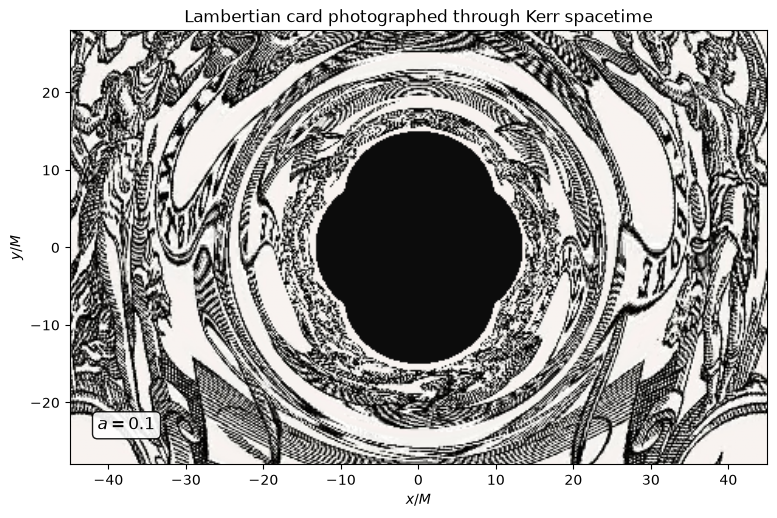

In [24]:
bh9 = grayt.BlackHole(a=0.1)
source = grayt.ImageSource(center=(-150.0, 0.0, 0.0),
                           normal=(1.0, 0.0, 0.0), up=(0.0, 0.0, 1.0),
                           width=90.0, height=68.0,
                           image=str(ASSETS / "labore_et_constantia.jpg"))
print("texture:", source.image.shape)

# PhysicalSystem holds the physics; integrator tolerances live on System.
ps = grayt.PhysicalSystem(spacetime=bh9)
ps.sources.append(source)
sys3 = grayt.System(physical=ps, rtol=1e-8, atol=1e-10)

cam = grayt.Camera(r=1000.0, theta=90.0, phi=0.0,
                   x=(-45.0, 45.0), y=(-28.0, 28.0), resolution=(450, 280))
t0 = time.time()
photo = sys3.photograph(cam, source, background=0.05)   # ~10 s, silent
print(f"photograph: {time.time()-t0:.1f} s")
vals, counts = np.unique(photo.status, return_counts=True)
print("ray status counts:", dict(zip(vals.tolist(), counts.tolist())),
      "(0 escaped, 1 captured, 2 reached source plane)")

ax = photo.plot(label=f"$a={bh9.a}$")
ax.set_xlabel("$x/M$"); ax.set_ylabel("$y/M$")
ax.set_title("Lambertian card photographed through Kerr spacetime")

The direct (distorted) image, the Einstein-ring secondary images and
the shadow all come out at 450×280 in about ten seconds.

## 6. 3D scene with traced rays

`System.trace_ray(origin, direction)` traces single geodesics from Cartesian
initial data and records them in `System.rays`; `System.visualize3d()` draws
horizon, disk annulus and rays (captured rays black, escaped colored). Note
the split: `PhysicalSystem` carries the spacetime and the objects in it,
while tracing, instruments and records live on `System`.

traced 24 rays, 15 captured


Text(0.5, 0.92, 'Null geodesics around $a=0.9$ (black = captured)')

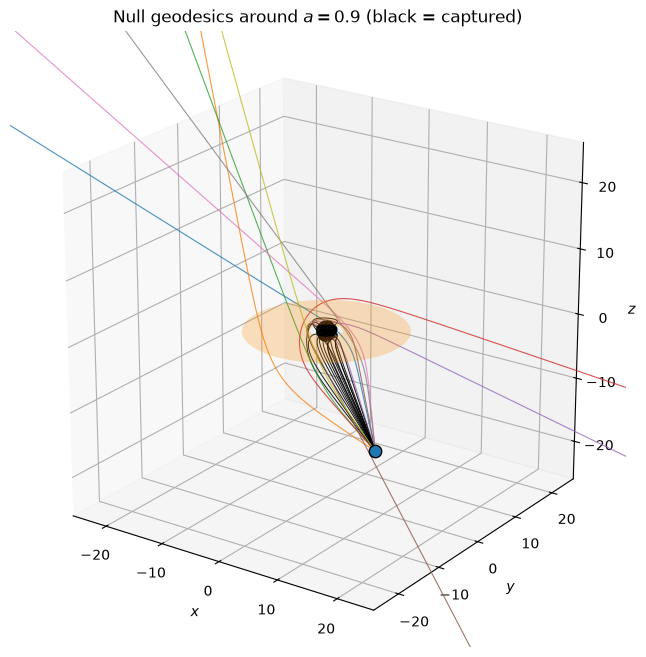

In [17]:
ps2 = grayt.PhysicalSystem(spacetime=grayt.BlackHole(a=0.9),
                           disk=grayt.ThinDisk(r_out=12.0))
scene = grayt.System(physical=ps2)

observer = np.array([18.0, -14.0, -9.0])
rng = np.random.default_rng(7)
target = -observer/np.linalg.norm(observer)
for _ in range(24):
    scene.trace_ray(observer, target + rng.normal(scale=0.16, size=3),
                    lambda_max=260.0)
n_cap = sum(r.status == grayt.STATUS_CAPTURED for r in scene.rays)
print(f"traced {len(scene.rays)} rays, {n_cap} captured")

ax3 = scene.visualize3d(show_surfaces=False, elev=22, azim=-55)
ax3.scatter(*observer, s=80, color="tab:blue", edgecolor="black", zorder=5)
lim = 26
ax3.set_xlim(-lim, lim); ax3.set_ylim(-lim, lim); ax3.set_zlim(-lim, lim)
ax3.set_title("Null geodesics around $a=0.9$ (black = captured)")

## 7. Edge cases: what happens on bad input?

A quick tour of failure modes, each wrapped in `try/except` so the notebook
still runs top-to-bottom. Verdicts inline.

In [18]:
# (a) Unphysical spin -- clean, informative ValueError. Good.
try:
    grayt.BlackHole(a=1.5)
except ValueError as e:
    print("BlackHole(a=1.5)      -> ValueError:", e)

# (b) ImageSource without an image -- clean ValueError. Good.
try:
    grayt.ImageSource(center=(-150, 0, 0))
except ValueError as e:
    print("ImageSource(no image) -> ValueError:", e)

# (c) orbit_ic with impossible (E, L) -- clean ValueError. Good.
try:
    grayt.orbit_ic(grayt.BlackHole(a=0.0), r0=10.0, energy=0.5,
                   angular_momentum=4.2)
except ValueError as e:
    print("orbit_ic(bad E,L)     -> ValueError:", e)

BlackHole(a=1.5)      -> ValueError: spin must satisfy |a| <= 1, got 1.5
ImageSource(no image) -> ValueError: ImageSource requires an image array or path
orbit_ic(bad E,L)     -> ValueError: no orbit with these (E, L) at r0: p_r^2 < 0


In [19]:
# (d) Disk entirely inside the ISCO: r_in defaults to the ISCO (= 6 for a=0),
# which is OUTSIDE r_out=3. The render still returns an all-zero image --
# there is nothing else it could return -- but it now says so out loud
# instead of handing back a silently empty result.
import warnings

bh0 = grayt.BlackHole(a=0.0)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    img_bad = grayt.render(bh0, grayt.Camera(resolution=(96, 48)),
                           grayt.ThinDisk(r_out=3.0))

print("ThinDisk(r_out=3) around a=0 (ISCO=6):")
for w in caught:
    print(f"  -> {w.category.__name__}: {w.message}")
print("  disk hits:", int((img_bad.status == grayt.STATUS_DISK).sum()),
      "   intensity max:", img_bad.intensity.max())

ThinDisk(r_out=3) around a=0 (ISCO=6):
  -> UserWarning: disk r_out = 3.0 lies inside the ISCO (6.000); the disk is empty
  disk hits: 0    intensity max: 0.0


In [20]:
# (e) Zero-resolution camera: rejected at construction. Previously `render`
# happily returned (0, 0) arrays and the mistake only surfaced much later,
# as an opaque numpy reduction failure inside plotting.
try:
    grayt.Camera(resolution=(0, 0))
except ValueError as e:
    print("Camera(resolution=(0,0)) -> ValueError:", e)

Camera(resolution=(0,0)) -> ValueError: resolution must be positive integers, got (0, 0)


In [21]:
# (f) The units trap: Camera.theta is in DEGREES. Passing radians used to be
# accepted silently, giving a face-on view instead of the intended edge-on
# one -- a plausible-looking but wrong image. It is now caught, and the
# message names the units and shows a sane value.
try:
    grayt.Camera(theta=np.pi/2)
except ValueError as e:
    print("Camera(theta=np.pi/2)    -> ValueError:", e)

# (g) Unknown integrator name: was a bare KeyError, now a ValueError that
# lists the valid methods.
try:
    grayt.render(grayt.BlackHole(), grayt.Camera(resolution=(8, 8)),
                 method="rk4")
except ValueError as e:
    print("method='rk4'             -> ValueError:", e)

Camera(theta=np.pi/2)    -> ValueError: theta = 1.5707963267948966 looks like radians; Camera.theta is in degrees (e.g. theta=85)
method='rk4'             -> ValueError: unknown integrator 'rk4'; valid methods: rkck45, rkdp45, rkf45


### Verdict on error handling

Validation is now uniformly early and explicit. Constructor-level checks
(`BlackHole`, `ImageSource`, `orbit_ic`, `Camera`) reject bad input with
messages that state what was wrong and, where it matters, what the correct
units or options are.

The four cases the original review flagged as *silent* have all been closed
since:

| case | then | now |
|---|---|---|
| disk entirely inside the ISCO | empty image, no signal | `UserWarning`, still an empty image |
| `resolution=(0, 0)` | `(0, 0)` arrays, opaque failure later in plotting | `ValueError` at construction |
| `Camera.theta` in radians | accepted, wrong physics, no warning | `ValueError` naming the units |
| unknown `method` | bare `KeyError` | `ValueError` listing valid methods |

Only the first still returns rather than raises, which is the right call —
an empty disk is a legitimate configuration, just rarely an intended one.

See `docs/reviews/notebook_user_review.md` for the original ergonomics review
that prompted these changes; note that its findings 1 and 2, and the
corresponding rows in `docs/REVIEW.md`, now describe fixed behaviour.